# Lire le dataset issu de l'étape feature engineering 

1. Chargement

In [91]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/step3_feature_engineering.csv')


print("Shape initial :", df.shape)
df.head()


Shape initial : (4372, 123)


,recency,frequency,monetarytotal,monetaryavg,monetarystd,avgquantitypertransaction,customertenuredays,firstpurchasedaysago,preferreddayofweek,preferredhour,...,country_Portugal,country_RSA,country_Saudi Arabia,country_Singapore,country_Spain,country_Sweden,country_Switzerland,country_USA,country_United Arab Emirates,country_Unspecified
0,302,11,3589.26875,16.950737,13.603662,5.426282,71,374,3,9,...,False,False,False,False,False,False,False,False,False,False
1,32,11,3079.10000,15.709694,11.684769,6.913265,342,374,2,13,...,False,False,False,False,False,False,False,False,False,False
2,3,11,3589.26875,28.634821,23.150132,19.956175,370,374,4,12,...,False,False,False,False,False,False,False,False,False,False
3,96,5,948.25000,33.866071,42.953119,15.678571,278,374,0,9,...,False,False,False,False,False,False,False,False,False,False
4,330,6,635.10000,105.850000,215.986263,9.666667,43,374,2,9,...,False,False,False,False,False,False,False,False,False,False


2. Vérification

In [92]:
print("Valeurs manquantes :", df.isnull().sum().sum())

Valeurs manquantes : 0


3. Séparer X / y

In [93]:
X = df.drop('churn', axis=1)
y = df['churn']

# X → données d’entrée
# y → ce que tu veux prédire

4. Train / Test Split

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

5. Encoding

In [95]:
# cat_cols = X_train.select_dtypes(include=['object']).columns

# X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
# Transformer texte → nombres
# X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# aligner colonnes
# X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
# 'left' on garde les colonnes de X_train
# On force les deux datasets à avoir les mêmes colonnes
# fill_value=0 si une colonne n'existe pas dans X_test → mettre 0

# Supprimer toutes les colonnes qui contiennent 'ChurnRiskCategory'
leak_cols = ['ChurnRiskCategory', 'CustomerType', 'RFMSegment', 'LoyaltyLevel']
X_train = X_train.drop(columns=[col for col in leak_cols if col in X_train.columns])
X_test  = X_test.drop(columns=[col for col in leak_cols if col in X_test.columns])
# --- Détection automatique des colonnes suspectes ---

# leak_cols = [col for col in X_train.columns if "churn" in col.lower()]
# if leak_cols:
#     print("⚠️ Colonnes fuite détectées :", leak_cols)
#     X_train = X_train.drop(columns=leak_cols)
#     X_test  = X_test.drop(columns=[col for col in leak_cols if col in X_test.columns])
# else:
#     print("✅ pas de fuite détectée !")


# Puis faire le get_dummies normalement
cat_cols = X_train.select_dtypes(include=['object']).columns
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)



6. Gestion des valeurs infinies / NaN

In [96]:
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

X_train.fillna(X_train.median(numeric_only=True), inplace=True)
X_test.fillna(X_train.median(numeric_only=True), inplace=True)

7. StandardScaler

In [97]:
# Mettre toutes les variables numériques à la même échelle
scaler = StandardScaler() #crées l’outil de normalisation

X_train_before = X_train.copy()

num_cols = X_train.select_dtypes(include=['int64','float64']).columns

X_train[num_cols] = scaler.fit_transform(X_train[num_cols]) #le scaler apprend sur TRAIN
X_test[num_cols] = scaler.transform(X_test[num_cols]) # le scaler applique la même transformation sur TEST

# Visualiser AVANT / APRÈS scaling

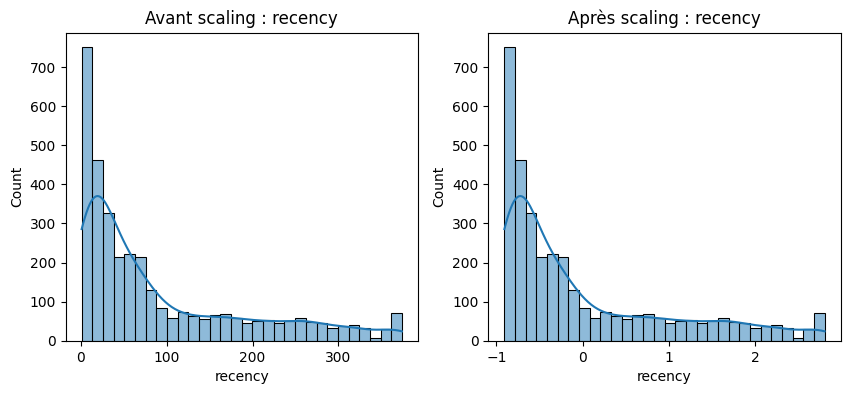

In [98]:


col = num_cols[0]  # une feature exemple

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(X_train_before[col], bins=30, kde=True)
plt.title(f"Avant scaling : {col}")

plt.subplot(1,2,2)
sns.histplot(X_train[col], bins=30, kde=True)
plt.title(f"Après scaling : {col}")

plt.show()


8. Analyse déséquilibre

In [99]:
print(y.value_counts())
# 0	Client fidèle	2918
# 1	Client parti	1454

churn
0    2918
1    1454
Name: count, dtype: int64


9. SMOTE

In [100]:
# pour équilibrer les classes 50/50
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(y_train_resampled.value_counts())

churn
0    2334
1    2334
Name: count, dtype: int64


# Visualiser AVANT / APRÈS SMOTE

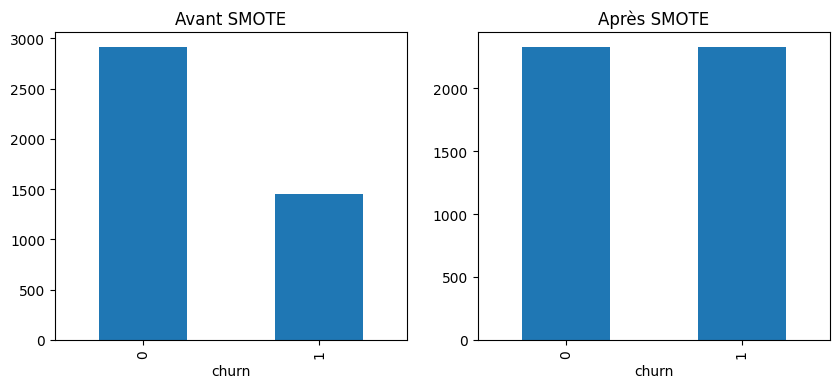

In [101]:
fig, axes = plt.subplots(1,2, figsize=(10,4))

y.value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title("Avant SMOTE")

y_train_resampled.value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title("Après SMOTE")

plt.show()


10. PCA

In [102]:
pca = PCA(n_components=27, random_state=42)

X_train_pca = pca.fit_transform(X_train_resampled)
X_test_pca = pca.transform(X_test)

explained_variance = pca.explained_variance_ratio_
print(f"Variance expliquée par 27 composantes : {explained_variance.sum()*100:.1f}%")
print("Shape PCA :", X_train_pca.shape)


Variance expliquée par 27 composantes : 86.1%
Shape PCA : (4668, 27)


# Visualiser PCA

1. Variance expliquée

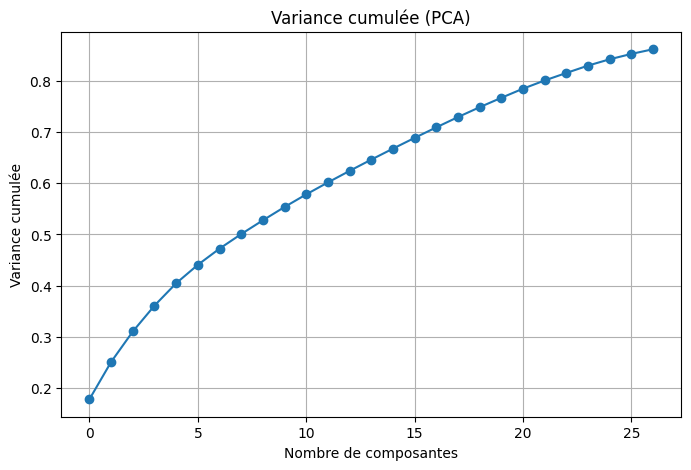

In [103]:

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.title("Variance cumulée (PCA)")
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance cumulée")
plt.grid()
plt.show()


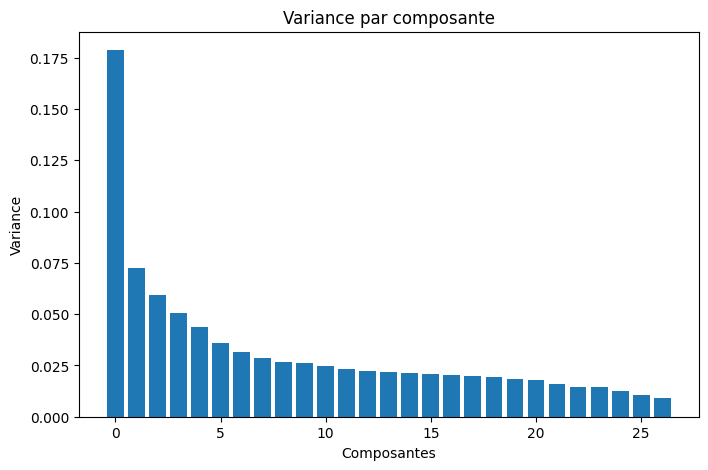

In [104]:
plt.figure(figsize=(8,5))
plt.bar(range(len(explained_variance)), explained_variance)
plt.title("Variance par composante")
plt.xlabel("Composantes")
plt.ylabel("Variance")
plt.show()


In [105]:
print(pca.components_)
components = pd.DataFrame(
    pca.components_, 
    columns=X_train.columns
)

# trier les poids de PC1
pc1 = components.iloc[0].abs().sort_values(ascending=False)

print(pc1.head(10))


[[-2.67035473e-01  2.85650561e-01  2.86547185e-01 ... -3.78828632e-04
  -3.11338908e-04 -1.32283108e-04]
 [-1.95042689e-01 -1.50021393e-01 -1.19374631e-03 ... -2.93468478e-04
   1.52671200e-04  6.36854468e-04]
 [ 3.50677005e-01  1.00755804e-02  9.96214939e-02 ...  5.40105223e-04
   1.09677569e-03  1.08731868e-04]
 ...
 [-1.92900544e-01  1.58844777e-01 -6.23424302e-02 ...  2.57622669e-04
  -7.55403425e-04 -9.56066567e-04]
 [ 1.50583836e-01 -8.33358496e-02 -4.20917169e-02 ... -5.47543844e-04
  -2.00803286e-04 -3.85498359e-05]
 [ 2.29534674e-02  1.65616318e-02 -9.74162689e-02 ... -8.43912669e-04
  -4.41777287e-04  9.64825950e-04]]
monetaryperday_log    0.316446
monetarytotal         0.286547
frequency             0.285651
customertenuredays    0.281384
tenureratio           0.279606
recency               0.267035
purchaseintensity     0.249802
uniqueproducts        0.219951
uniqueinvoices        0.208978
returnimpact_log      0.203018
Name: 0, dtype: float64


2. Projection 2D

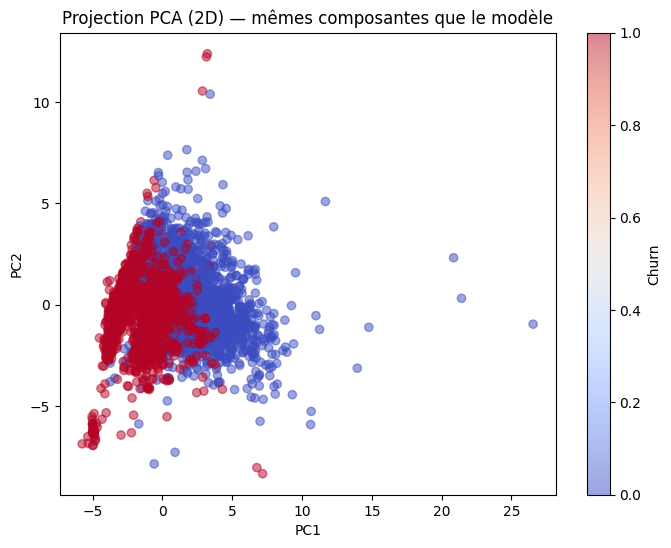

In [106]:
X_2d = pca.transform(X_train_resampled)[:, :2]

plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c=y_train_resampled, cmap='coolwarm', alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Projection PCA (2D) — mêmes composantes que le modèle")
plt.colorbar(label="Churn")
plt.show()


# Vérification finale dataset

In [107]:
print("Shape final :", X_train_pca.shape)
print("Valeurs manquantes :", X_train.isnull().sum().sum())


Shape final : (4668, 27)
Valeurs manquantes : 0


11. Sauvegarde

In [108]:
# version classique
X_train.to_csv('../data/train_test/X_train.csv', index=False)
X_test.to_csv('../data/train_test/X_test.csv', index=False)

# version SMOTE
pd.DataFrame(X_train_resampled).to_csv('../data/train_test/X_train_smote.csv', index=False)
pd.DataFrame(y_train_resampled).to_csv('../data/train_test/y_train_smote.csv', index=False)

# version PCA
pd.DataFrame(X_train_pca).to_csv('../data/train_test/X_train_pca.csv', index=False)
pd.DataFrame(X_test_pca).to_csv('../data/train_test/X_test_pca.csv', index=False)

# labels
y_train.to_csv('../data/train_test/y_train.csv', index=False)
y_test.to_csv('../data/train_test/y_test.csv', index=False)


print("Données sauvegardées !")


Données sauvegardées !
